In [1]:
!pip install -U diffusers transformers accelerate safetensors huggingface_hub invisible_watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 50.0 MB/s  0:00:00


In [2]:
import os
import torch
from PIL import Image
import matplotlib.pyplot as plt

from diffusers import AutoPipelineForInpainting

print("torch:", torch.__version__)
print("cuda:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


torch: 2.6.0+cu124
cuda: True
gpu: NVIDIA GeForce RTX 4060 Ti


In [6]:
BASE_DIR = "/home/harry/Re_leaf_Project/Inpainting"

ORIGINAL_DIR = os.path.join(BASE_DIR, "original")
MASK_DIR = os.path.join(BASE_DIR, "mask")
OUTPUT_DIR = os.path.join(BASE_DIR, "output_sdxl")

os.makedirs(OUTPUT_DIR, exist_ok=True)

IMAGE_NAME = "Tomato Early Blight2.jpg"
MASK_NAME = "Tomato Early Blight2.png"

image_path = os.path.join(ORIGINAL_DIR, IMAGE_NAME)
mask_path = os.path.join(MASK_DIR, MASK_NAME)

print(image_path)
print(mask_path)

/home/harry/Re_leaf_Project/Inpainting/original/Tomato Early Blight2.jpg
/home/harry/Re_leaf_Project/Inpainting/mask/Tomato Early Blight2.png


In [7]:
def resize_to_multiple_of_8(img, max_size=1024):
    w, h = img.size
    
    scale = min(max_size / w, max_size / h)
    new_w = int(w * scale)
    new_h = int(h * scale)

    new_w = (new_w // 8) * 8
    new_h = (new_h // 8) * 8

    return img.resize((new_w, new_h), Image.LANCZOS)


image = Image.open(image_path).convert("RGB")
mask = Image.open(mask_path).convert("L")

image = resize_to_multiple_of_8(image, max_size=1024)
mask = mask.resize(image.size, Image.NEAREST)

print("image size:", image.size)
print("mask size:", mask.size)

image size: (1024, 808)
mask size: (1024, 808)


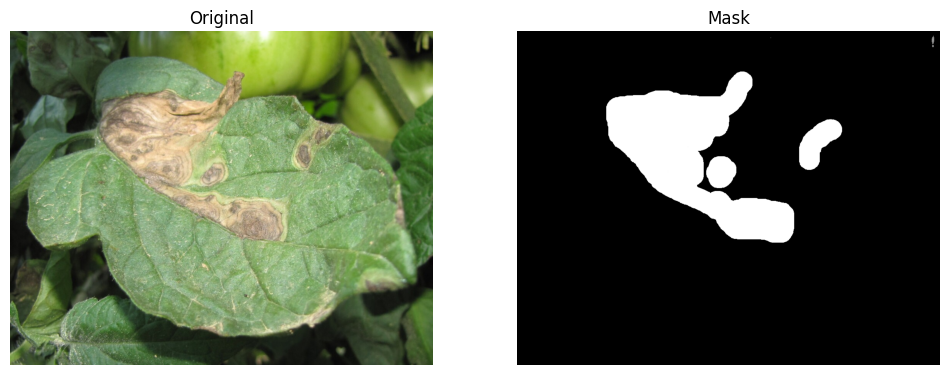

In [8]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [9]:
model_id = "diffusers/stable-diffusion-xl-1.0-inpainting-0.1"

pipe = AutoPipelineForInpainting.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

pipe = pipe.to("cuda")

pipe.enable_attention_slicing()
pipe.enable_vae_slicing()

print("SDXL Inpainting 로드 완료")

/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

SDXL Inpainting 로드 완료


/home/harry/miniconda3/envs/pytorch_gpu/lib/python3.11/site-packages/diffusers/pipelines/pipeline_utils.py:2267: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLInpaintPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [10]:
prompt = """
close-up photo of a natural green plant leaf surface,
preserve the original leaf shape,
preserve existing leaf veins,
same lighting,
same camera perspective,
realistic leaf texture,
subtle repair,
minimal change,
photorealistic
"""

negative_prompt = """
tomato fruit,
red fruit,
green fruit,
new objects,
extra leaves,
new plant parts,
folded leaf,
paper texture,
plastic texture,
painted texture,
artificial geometry,
deformed veins,
distorted leaf,
fake pattern,
cartoon,
illustration,
blur,
oversmooth,
hallucinated content
"""

  0%|          | 0/19 [00:00<?, ?it/s]

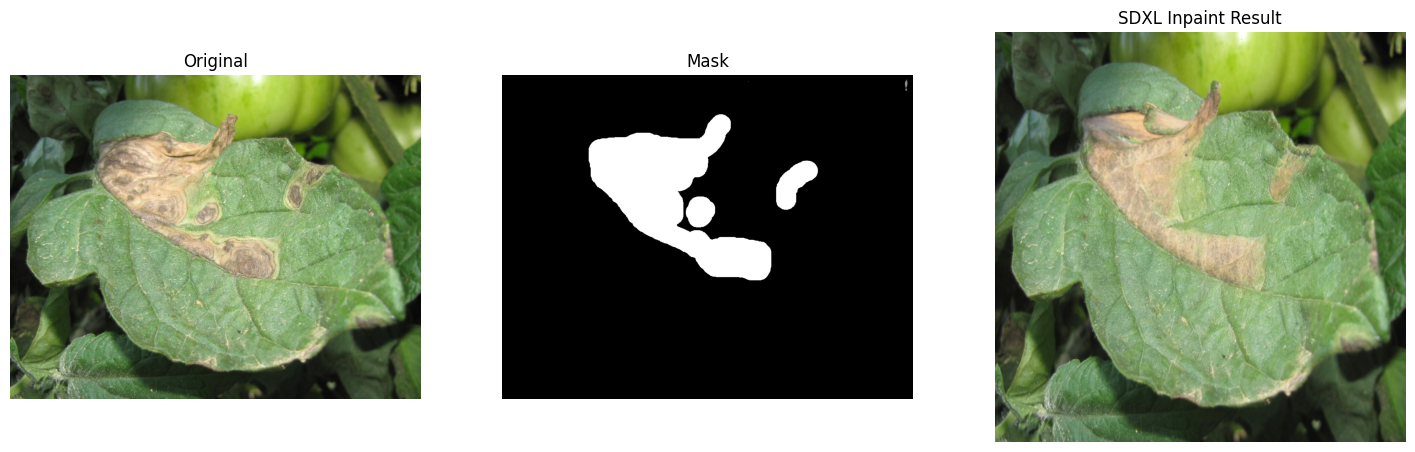

In [11]:
generator = torch.Generator(device="cuda").manual_seed(42)

result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=image,
    mask_image=mask,
    strength=0.38,
    guidance_scale=4.5,
    num_inference_steps=50,
    generator=generator
).images[0]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title("SDXL Inpaint Result")
plt.axis("off")

plt.show()

In [12]:
test_settings = [
    {"strength": 0.30, "guidance_scale": 4.0, "steps": 50, "seed": 42},
    {"strength": 0.35, "guidance_scale": 4.0, "steps": 50, "seed": 42},
    {"strength": 0.40, "guidance_scale": 4.5, "steps": 50, "seed": 42},
    {"strength": 0.45, "guidance_scale": 4.5, "steps": 60, "seed": 42},
    {"strength": 0.50, "guidance_scale": 5.0, "steps": 60, "seed": 42},
]

results = []

for setting in test_settings:
    generator = torch.Generator(device="cuda").manual_seed(setting["seed"])

    out = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=image,
        mask_image=mask,
        strength=setting["strength"],
        guidance_scale=setting["guidance_scale"],
        num_inference_steps=setting["steps"],
        generator=generator
    ).images[0]

    filename = f"sdxl_s{setting['strength']}_cfg{setting['guidance_scale']}_steps{setting['steps']}_seed{setting['seed']}.png"
    save_path = os.path.join(OUTPUT_DIR, filename)
    out.save(save_path)

    results.append((setting, out))

print("비교 이미지 생성 완료")

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/17 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

비교 이미지 생성 완료


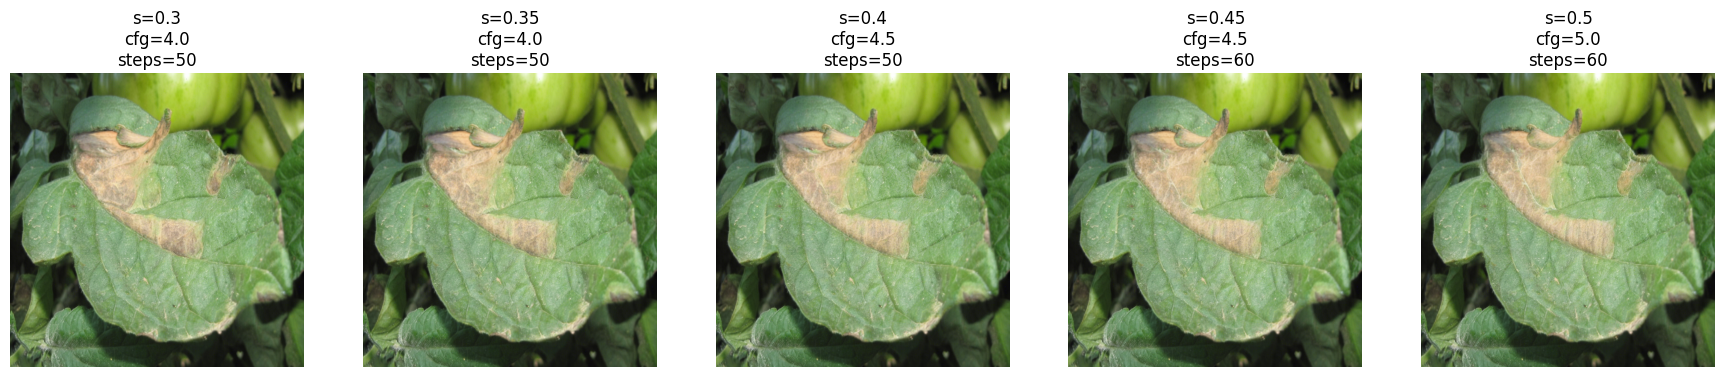

In [13]:
plt.figure(figsize=(22, 6))

for i, (setting, out) in enumerate(results):
    plt.subplot(1, len(results), i + 1)
    plt.imshow(out)
    plt.title(
        f"s={setting['strength']}\n"
        f"cfg={setting['guidance_scale']}\n"
        f"steps={setting['steps']}"
    )
    plt.axis("off")

plt.show()